# Eurostat & Climate DT Visualisation

This notebook has three parts:

1. **Eurostat** — fetch life-expectancy-at-birth data from the Eurostat API and plot it as a choropleth map of Europe.
2. **Climate DT** — fetch 2 m temperature for the same set of countries from the DestinE Climate DT via Polytope and plot it in the same style.
3. **Climate Health Hazard Index** — combine Climate DT summer heat (present baseline and SSP3-7.0 future) with Eurostat elderly population share to produce a composite hazard score per country, shown as three maps: present, future, and the change between them.

All maps use the same NUTS Level-0 shapefile and the same `earthkit.plots` rendering pipeline so the results are directly comparable.

---
## Part 1 — Eurostat life expectancy

In [2]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import earthkit.plots

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/tps00205?lang=EN&time=2024"
resp = requests.get(url)
data = resp.json()

In [3]:
geo_code = data['dimension']["geo"]["category"]["index"]
new_dict = []
for key, value in geo_code.items():
    if str(value) in data['value'] and key != 'EU27_2020':
        new_dict.append((key, data['value'][str(value)]))

In [4]:
df = pd.DataFrame(new_dict, columns=["geo", "value"])
df

,geo,value
0,EA21,82.2
1,EA20,82.4
2,BE,82.4
3,BG,75.8
4,CZ,80.1
5,DK,82.0
6,DE,81.2
7,EE,79.4
8,IE,83.1
9,EL,81.9


In [6]:
# Path to your local shapefile archive
shapefile_path = "data/NUTS_RG_20M_2021_4326_LEVL_0.shp.zip"

# Load the shapefile into a GeoDataFrame
gdf = gpd.read_file(f"zip://{shapefile_path}")
gdf

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,FR,0,FR,France,France,0,0,0,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -..."
1,HR,0,HR,Hrvatska,Hrvatska,0,0,0,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46...."
2,HU,0,HU,Magyarország,Magyarország,0,0,0,"POLYGON ((21.42465 48.57472, 21.60691 48.49458..."
3,AL,0,AL,Shqipëria,Shqipëria,0,0,0,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ..."
4,AT,0,AT,Österreich,Österreich,0,0,0,"POLYGON ((15.75363 48.85218, 16.29009 48.73395..."
5,BE,0,BE,Belgique/België,Belgique/België,0,0,0,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5...."
6,BG,0,BG,Bulgaria,България,0,0,0,"POLYGON ((22.85777 43.87577, 22.99717 43.80787..."
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0,0,0,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8..."
8,CY,0,CY,Kýpros,Κύπρος,0,0,0,"POLYGON ((32.27382 35.06649, 32.28884 35.10503..."
9,CZ,0,CZ,Česko,Česko,0,0,0,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ..."


In [7]:
# Create color scale
cmap = plt.get_cmap("Reds")

# Normalize values between 0 and 1 for color mapping
norm = plt.Normalize(vmin=df["value"].min(), vmax=df["value"].max())

# Map numeric values to colors in hex format
df["facecolor"] = df["value"].apply(lambda x: plt.cm.colors.to_hex(cmap(norm(x))))

print(df)

     geo  value facecolor
0   EA21   82.2   #c1161b
1   EA20   82.4   #b91419
2     BE   82.4   #b91419
3     BG   75.8   #fee5d9
4     CZ   80.1   #f5533b
5     DK   82.0   #c7171c
6     DE   81.2   #e02c26
7     EE   79.4   #fb7050
8     IE   83.1   #a10e15
9     EL   81.9   #ca181d
10    ES   84.0   #71020e
11    FR   83.0   #a60f15
12    HR   78.9   #fc8060
13    IT   83.7   #800610
14    CY   83.5   #8c0912
15    LV   76.4   #fdd5c4
16    LT   77.5   #fcb296
17    LU   83.2   #9c0d14
18    HU   76.8   #fdc9b3
19    MT   83.0   #a60f15
20    NL   81.9   #ca181d
21    AT   82.1   #c3161b
22    PL   78.5   #fc8e6e
23    PT   82.5   #b61319
24    RO   76.5   #fdd2bf
25    SI   82.1   #c3161b
26    SK   78.4   #fc9272
27    FI   82.2   #c1161b
28    SE   83.8   #7c0510
29    IS   82.8   #ac1117
30    LI   84.2   #67000d
31    NO   83.2   #9c0d14
32    CH   84.2   #67000d
33    ME   77.6   #fcae92
34    AL   80.4   #f24734
35    RS   76.2   #fedccd
36    TR   79.0   #fb7d5d
37    GE   7

In [8]:
# Merge — keep all geometries, even if no data
gdf_full = gdf.merge(
    df,
    left_on="NUTS_ID",
    right_on="geo",
    how="left"
)

# Convert to GeoDataFrame if needed
if not isinstance(gdf_full, gpd.GeoDataFrame):
    gdf_full = gpd.GeoDataFrame(gdf_full, geometry=gdf.geometry, crs=gdf.crs)

gdf_full["facecolor"] = gdf_full["facecolor"].fillna("#cccccc")
gdf_full

,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,geo,value,facecolor
0,FR,0,FR,France,France,0,0,0,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -...",FR,83.0,#a60f15
1,HR,0,HR,Hrvatska,Hrvatska,0,0,0,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46....",HR,78.9,#fc8060
2,HU,0,HU,Magyarország,Magyarország,0,0,0,"POLYGON ((21.42465 48.57472, 21.60691 48.49458...",HU,76.8,#fdc9b3
3,AL,0,AL,Shqipëria,Shqipëria,0,0,0,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ...",AL,80.4,#f24734
4,AT,0,AT,Österreich,Österreich,0,0,0,"POLYGON ((15.75363 48.85218, 16.29009 48.73395...",AT,82.1,#c3161b
5,BE,0,BE,Belgique/België,Belgique/België,0,0,0,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5....",BE,82.4,#b91419
6,BG,0,BG,Bulgaria,България,0,0,0,"POLYGON ((22.85777 43.87577, 22.99717 43.80787...",BG,75.8,#fee5d9
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0,0,0,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8...",CH,84.2,#67000d
8,CY,0,CY,Kýpros,Κύπρος,0,0,0,"POLYGON ((32.27382 35.06649, 32.28884 35.10503...",CY,83.5,#8c0912
9,CZ,0,CZ,Česko,Česko,0,0,0,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ...",CZ,80.1,#f5533b


In [9]:
# Merge on country code — only keep countries with data
gdf_joined = gdf.merge(
    df,
    left_on="NUTS_ID",
    right_on="geo",
    how="inner"
)

# Ensure result is a GeoDataFrame with correct geometry
gdf_joined = gpd.GeoDataFrame(gdf_joined, geometry="geometry", crs=gdf.crs)

# Drop redundant columns
gdf_joined = gdf_joined[["NUTS_ID", "value", "facecolor", "geometry"]]
gdf_joined

,NUTS_ID,value,facecolor,geometry
0,FR,83.0,#a60f15,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -..."
1,HR,78.9,#fc8060,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46...."
2,HU,76.8,#fdc9b3,"POLYGON ((21.42465 48.57472, 21.60691 48.49458..."
3,AL,80.4,#f24734,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ..."
4,AT,82.1,#c3161b,"POLYGON ((15.75363 48.85218, 16.29009 48.73395..."
5,BE,82.4,#b91419,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5...."
6,BG,75.8,#fee5d9,"POLYGON ((22.85777 43.87577, 22.99717 43.80787..."
7,CH,84.2,#67000d,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8..."
8,CY,83.5,#8c0912,"POLYGON ((32.27382 35.06649, 32.28884 35.10503..."
9,CZ,80.1,#f5533b,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ..."


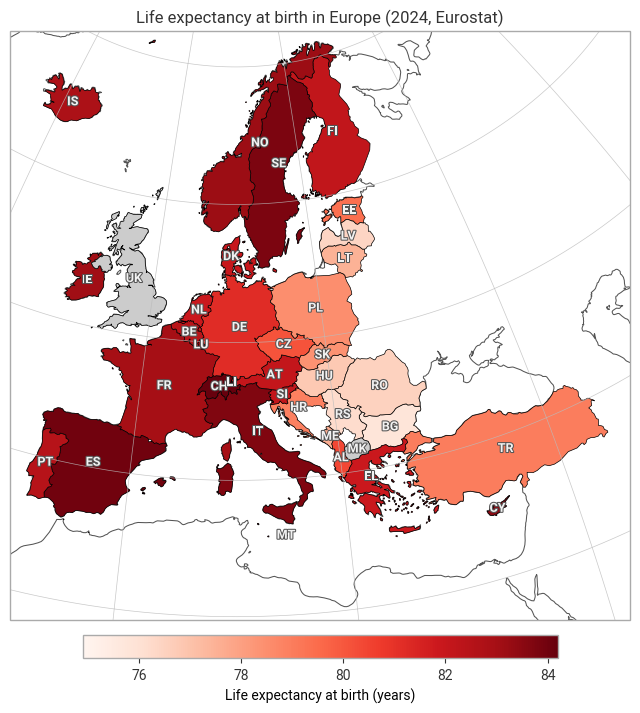

In [10]:
chart = earthkit.plots.Map(domain="Europe")

chart.coastlines()
chart.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_full['facecolor'],
    cmap="Reds",
    edgecolor="black",
    linewidth=0.5,
)
chart.gridlines(draw_labels=False)
chart.title("Life expectancy at birth in Europe (2024, Eurostat)")
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])
chart.fig.colorbar(sm, ax=chart.ax, orientation="horizontal", pad=0.02, shrink=0.6, label="Life expectancy at birth (years)")
chart.show()

---
## Part 2 — Climate DT 2 m temperature via Polytope

For each country we fetch all 12 monthly-mean 2 m temperature (`avg_2t`) fields from the DestinE Climate DT (IFS-NEMO, historical run) using a **polygon** feature request that covers the country boundary. The grid points inside the polygon are spatially averaged to give one value per month, then averaged across months to give an annual mean temperature per country.

Using polygon requests rather than single-point centroids gives a more representative country-level temperature by averaging over the full land area.

> **Note:** You need a valid DESP account with Climate DT access.  
> Run `desp-authentication.py` once to store your token in `~/.polytopeapirc`.


In [64]:
#%%capture cap
#%run ../../desp-authentication.py

In [65]:
#output_1 = cap.stdout.split('}\n')
#access_token = output_1[-1][0:-1]

In [11]:
import earthkit.data
import numpy as np

# Set to False to load from a previously saved cache file instead of making live requests
import os
LIVE_REQUEST = os.getenv("LIVE_REQUEST", "true").lower() == "false"
print(f"LIVE_REQUEST = {LIVE_REQUEST}")

LIVE_REQUEST = False


In [12]:
import earthkit.geo.cartography

# Countries to request — earthkit.geo resolves these to polygon shapes.
# Must match the Eurostat NUTS-0 codes used later for the choropleth merge.
COUNTRY_NAMES = [
    ("BE", "Belgium"),
    ("BG", "Bulgaria"),
    ("CZ", "Czech Republic"),
    ("DK", "Denmark"),
    ("DE", "Germany"),
    ("EE", "Estonia"),
    ("EL", "Greece"),
    ("ES", "Spain"),
    ("FR", "France"),
    ("HR", "Croatia"),
    ("IT", "Italy"),
    ("CY", "Cyprus"),
    ("LV", "Latvia"),
    ("LT", "Lithuania"),
    ("LU", "Luxembourg"),
    ("HU", "Hungary"),
    ("NL", "Netherlands"),
    ("AT", "Austria"),
    ("PL", "Poland"),
    ("PT", "Portugal"),
    ("RO", "Romania"),
    ("SI", "Slovenia"),
    ("SK", "Slovakia"),
    ("FI", "Finland"),
    ("SE", "Sweden"),
    ("IS", "Iceland"),
    ("NO", "Norway"),
    ("CH", "Switzerland"),
]

country_codes = [c[0] for c in COUNTRY_NAMES]
print(f"{len(COUNTRY_NAMES)} countries defined")


28 countries defined


In [13]:
# ── Configuration ────────────────────────────────────────────────────────────
CDT_YEAR    = "2010"
CDT_MONTHS  = [str(m) for m in range(1, 13)]  # all 12 months
CDT_MODEL   = "ifs-nemo"
CDT_PARAM   = "avg_2t"   # Time-mean 2 m temperature [K]
CDT_ADDRESS = "polytope.mn5.apps.dte.destination-earth.eu"

def make_polygon_request(shape, year, month):
    """Build a clmn polygon request for a single country shape and month."""
    return {
        "activity":    "baseline",
        "class":       "d1",
        "dataset":     "climate-dt",
        "experiment":  "hist",
        "generation":  "2",
        "levtype":     "sfc",
        "year":        year,
        "month":       month,
        "model":       CDT_MODEL,
        "expver":      "0001",
        "param":       CDT_PARAM,
        "realization": "1",
        "resolution":  "standard",
        "stream":      "clmn",
        "type":        "fc",
        "feature": {
            "type":  "polygon",
            "shape": shape,
        },
    }

print(f"Requesting {CDT_PARAM} polygon for {len(COUNTRY_NAMES)} countries, {len(CDT_MONTHS)} months — {CDT_YEAR}")


Requesting avg_2t polygon for 28 countries, 12 months — 2010


In [14]:
import numpy as np
import os

# One request per country per month; spatially average the polygon points,
# then average across months to get one annual mean per country.
country_annual_K = {}  # geo_code → mean annual temp [K]

for geo_code, country_name in COUNTRY_NAMES:
    shape = earthkit.geo.cartography.country_polygons([country_name], resolution=50e6)
    monthly_means = []
    for month in CDT_MONTHS:
        cache = f"data/cdt_polygon_{geo_code}_{CDT_YEAR}_{month.zfill(2)}.covjson"
        req = make_polygon_request(shape, CDT_YEAR, month)
        if LIVE_REQUEST:
            raw = earthkit.data.from_source(
                "polytope", "destination-earth", req,
                address=CDT_ADDRESS, stream=False
            )
            raw.to_target("file", cache)
        else:
            raw = earthkit.data.from_source("file", cache)
        ds = raw.to_xarray()
        # Spatial mean over all grid points inside the polygon
        monthly_means.append(float(np.nanmean(ds[CDT_PARAM].values)))
    country_annual_K[geo_code] = float(np.nanmean(monthly_means))
    print(f"  {geo_code} ({country_name}): {country_annual_K[geo_code] - 273.15:.1f} °C")

print("\nDone.")


  BE (Belgium): 10.6 °C
  BG (Bulgaria): 12.2 °C
  CZ (Czech Republic): 9.4 °C
  DK (Denmark): 8.5 °C
  DE (Germany): 9.7 °C
  EE (Estonia): 5.7 °C
  EL (Greece): 14.6 °C
  ES (Spain): 14.5 °C
  FR (France): 11.9 °C
  HR (Croatia): 12.8 °C
  IT (Italy): 14.0 °C
  CY (Cyprus): 18.3 °C
  LV (Latvia): 6.4 °C
  LT (Lithuania): 7.0 °C
  LU (Luxembourg): 9.9 °C
  HU (Hungary): 12.7 °C
  NL (Netherlands): 10.6 °C
  AT (Austria): 8.2 °C
  PL (Poland): 9.1 °C
  PT (Portugal): 16.0 °C
  RO (Romania): 11.2 °C
  SI (Slovenia): 11.3 °C
  SK (Slovakia): 9.2 °C
  FI (Finland): 2.0 °C
  SE (Sweden): 2.9 °C
  IS (Iceland): -0.6 °C
  NO (Norway): 0.6 °C
  CH (Switzerland): 5.7 °C

Done.


In [15]:
temp_values_C = [country_annual_K[c] - 273.15 for c in country_codes]

df_cdt = pd.DataFrame({
    "geo":   country_codes,
    "value": temp_values_C,
})

df_cdt


,geo,value
0,BE,10.562684
1,BG,12.222879
2,CZ,9.421261
3,DK,8.539009
4,DE,9.682359
5,EE,5.698614
6,EL,14.632619
7,ES,14.525349
8,FR,11.912908
9,HR,12.766559


In [16]:
# Build a color scale — RdYlBu_r so warm = red, cold = blue
cmap_cdt = plt.get_cmap("RdYlBu_r")
norm_cdt  = plt.Normalize(vmin=df_cdt["value"].min(), vmax=df_cdt["value"].max())

df_cdt["facecolor"] = df_cdt["value"].apply(
    lambda x: plt.cm.colors.to_hex(cmap_cdt(norm_cdt(x)))
)

print(df_cdt)


   geo      value facecolor
0   BE  10.562684   #fee294
1   BG  12.222879   #fdb96b
2   CZ   9.421261   #fff6b1
3   DK   8.539009   #fafdc9
4   DE   9.682359   #fff1aa
5   EE   5.698614   #bde2ee
6   EL  14.632619   #f26841
7   ES  14.525349   #f36b42
8   FR  11.912908   #fdc173
9   HR  12.766559   #fca85e
10  IT  13.962425   #f67f4b
11  CY  18.275896   #a50026
12  LV   6.351208   #cfebf3
13  LT   6.972223   #e0f3f8
14  LU   9.930190   #feeda4
15  HU  12.747424   #fcaa5f
16  NL  10.579770   #fee294
17  AT   8.204012   #f5fbd2
18  PL   9.118745   #fffbb9
19  PT  16.017598   #dc3b2c
20  RO  11.185134   #fed485
21  SI  11.345498   #fed081
22  SK   9.199230   #fffab7
23  FI   2.025731   #578abf
24  SE   2.855152   #6ba2cb
25  IS  -0.574082   #313695
26  NO   0.607200   #3e5ea8
27  CH   5.692235   #bde2ee


In [17]:
# Merge Climate DT values onto the NUTS shapefile (left join — keep all shapes)
gdf_cdt = gdf.merge(
    df_cdt,
    left_on="NUTS_ID",
    right_on="geo",
    how="left"
)

if not isinstance(gdf_cdt, gpd.GeoDataFrame):
    gdf_cdt = gpd.GeoDataFrame(gdf_cdt, geometry=gdf.geometry, crs=gdf.crs)

# Grey out countries with no Climate DT data
gdf_cdt["facecolor"] = gdf_cdt["facecolor"].fillna("#cccccc")
gdf_cdt


,NUTS_ID,LEVL_CODE,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry,geo,value,facecolor
0,FR,0,FR,France,France,0,0,0,"MULTIPOLYGON (((55.21471 -21.03851, 55.27392 -...",FR,11.912908,#fdc173
1,HR,0,HR,Hrvatska,Hrvatska,0,0,0,"MULTIPOLYGON (((16.59681 46.4759, 16.85476 46....",HR,12.766559,#fca85e
2,HU,0,HU,Magyarország,Magyarország,0,0,0,"POLYGON ((21.42465 48.57472, 21.60691 48.49458...",HU,12.747424,#fcaa5f
3,AL,0,AL,Shqipëria,Shqipëria,0,0,0,"POLYGON ((19.73492 42.63238, 19.831 42.46645, ...",NaN,NaN,#cccccc
4,AT,0,AT,Österreich,Österreich,0,0,0,"POLYGON ((15.75363 48.85218, 16.29009 48.73395...",AT,8.204012,#f5fbd2
5,BE,0,BE,Belgique/België,Belgique/België,0,0,0,"POLYGON ((4.75993 51.50246, 4.864 51.43362, 5....",BE,10.562684,#fee294
6,BG,0,BG,Bulgaria,България,0,0,0,"POLYGON ((22.85777 43.87577, 22.99717 43.80787...",BG,12.222879,#fdb96b
7,CH,0,CH,Schweiz/Suisse/Svizzera,Schweiz/Suisse/Svizzera,0,0,0,"POLYGON ((8.67046 47.68486, 8.79571 47.6756, 8...",CH,5.692235,#bde2ee
8,CY,0,CY,Kýpros,Κύπρος,0,0,0,"POLYGON ((32.27382 35.06649, 32.28884 35.10503...",CY,18.275896,#a50026
9,CZ,0,CZ,Česko,Česko,0,0,0,"POLYGON ((14.6188 50.8578, 14.76738 50.81985, ...",CZ,9.421261,#fff6b1


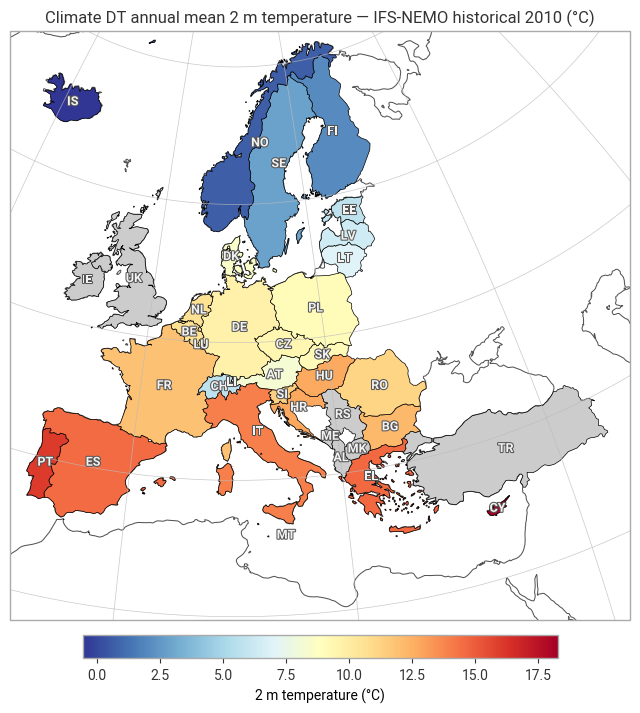

In [18]:
chart_cdt = earthkit.plots.Map(domain="Europe")

chart_cdt.coastlines()
chart_cdt.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_cdt["facecolor"],
    cmap="RdYlBu_r",
    edgecolor="black",
    linewidth=0.5,
)
chart_cdt.gridlines(draw_labels=False)
chart_cdt.title(f"Climate DT annual mean 2 m temperature — {CDT_MODEL.upper()} historical {CDT_YEAR} (°C)")
sm_cdt = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=norm_cdt)
sm_cdt.set_array([])
chart_cdt.fig.colorbar(sm_cdt, ax=chart_cdt.ax, orientation="horizontal", pad=0.02, shrink=0.6, label="2 m temperature (°C)")
chart_cdt.show()


### SSP3-7.0 projections (2040–2049 JJA mean)

The same map using the future scenario temperatures from Part 3 — JJA mean 2 m temperature averaged over 2040–2049 under SSP3-7.0.


In [74]:
# (see cells above)


---
## Part 3 — Climate Health Hazard Index

We combine two independently normalised pillars into a composite **Climate Health Hazard Score** for each country:

```
HazardScore = w_climate × ClimateScore + w_vuln × VulnerabilityScore
```

| Pillar | Source | Variable | Rationale |
|--------|--------|----------|-----------|
| **Climate** | Climate DT (`clmn`, `avg_2t`) | Mean summer (JJA) temperature | Direct heat exposure; computed for a **present** baseline (hist 2005–2014) and a **future** scenario (SSP3-7.0 2040–2049) |
| **Vulnerability** | Eurostat `tps00010` | Share of population aged 65+ | Older people are the primary mortality group in heat waves; higher share = more vulnerable |

Three maps are produced:
1. **Present hazard** — composite score using hist baseline temperatures
2. **Future hazard** — composite score using SSP3-7.0 mid-century temperatures
3. **Change** — future minus present, showing where risk increases most

> **Note:** The Climate DT requests in this section fetch multi-month data (June–August) for a 10-year period per scenario.  
> Each request may take several minutes. Set `LIVE_REQUEST = False` to use cached files after the first run.

In [19]:
# ── Fetch elderly population share (65+) from Eurostat ───────────────────────
# Dataset TPS00010: share of population aged 65 and over, most recent year
# The flat value array is ordered: indic_de × geo × time (n_geo=53, n_time=1)
# PC_Y65_79 has indic_de index 4; PC_Y80_MAX has indic_de index 5
# Flat index for a given geo_pos: indic_pos * n_geo + geo_pos
url_elderly = (
    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/"
    "tps00010?lang=EN&time=2023"
)
resp_elderly = requests.get(url_elderly)
data_elderly = resp_elderly.json()

geo_idx    = data_elderly['dimension']['geo']['category']['index']
indic_idx  = data_elderly['dimension']['indic_de']['category']['index']
n_geo      = len(geo_idx)
idx_65_79  = indic_idx['PC_Y65_79']   # 4
idx_80_max = indic_idx['PC_Y80_MAX']  # 5

EXCLUDE = {'EU27_2020', 'EA21', 'EA20', 'EA19'}
elderly_rows = []
for code, geo_pos in geo_idx.items():
    if code in EXCLUDE:
        continue
    flat_65_79  = idx_65_79  * n_geo + geo_pos
    flat_80_max = idx_80_max * n_geo + geo_pos
    v65 = data_elderly['value'].get(str(flat_65_79),  float('nan'))
    v80 = data_elderly['value'].get(str(flat_80_max), float('nan'))
    elderly_rows.append((code, v65, v80, v65 + v80))

df_elderly = pd.DataFrame(elderly_rows, columns=['geo', 'pct_65_79', 'pct_80_plus', 'elderly_pct'])
print(f"Elderly share data for {len(df_elderly)} countries")
df_elderly

Elderly share data for 49 countries


,geo,pct_65_79,pct_80_plus,elderly_pct
0,BE,14.2,5.5,19.7
1,BG,18.4,5.1,23.5
2,CZ,16.1,4.3,20.4
3,DK,15.3,5.1,20.4
4,DE,15.0,7.2,22.2
5,EE,14.4,5.9,20.3
6,IE,11.6,3.6,15.2
7,EL,15.9,7.1,23.0
8,ES,14.2,6.0,20.2
9,FR,15.2,5.9,21.1


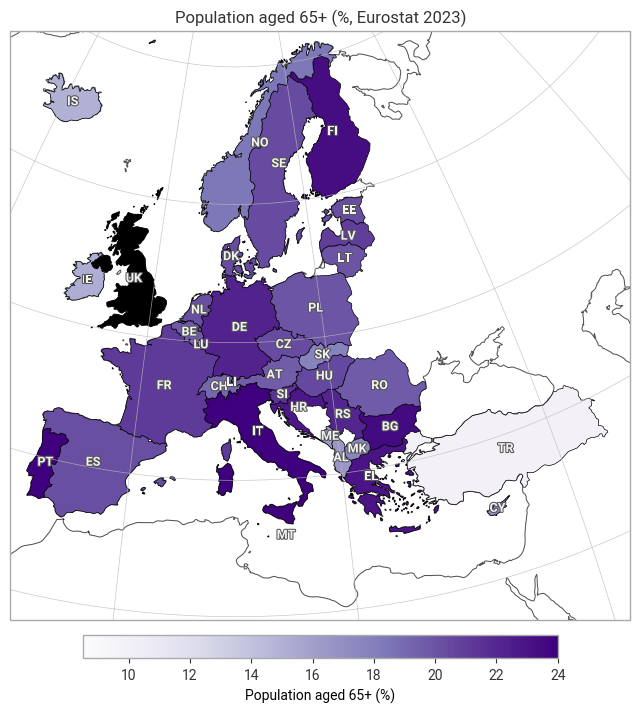

In [20]:
# ── Plot elderly population share ────────────────────────────────────────────
cmap_elderly = plt.get_cmap("Purples")
norm_elderly = plt.Normalize(
    vmin=df_elderly["elderly_pct"].min(),
    vmax=df_elderly["elderly_pct"].max(),
)

df_elderly["facecolor"] = df_elderly["elderly_pct"].apply(
    lambda x: plt.cm.colors.to_hex(cmap_elderly(norm_elderly(x)))
)

gdf_elderly = gdf.merge(df_elderly, left_on="NUTS_ID", right_on="geo", how="left")
if not isinstance(gdf_elderly, gpd.GeoDataFrame):
    gdf_elderly = gpd.GeoDataFrame(gdf_elderly, geometry=gdf.geometry, crs=gdf.crs)
gdf_elderly["facecolor"] = gdf_elderly["facecolor"].fillna("#cccccc")

chart_elderly = earthkit.plots.Map(domain="Europe")
chart_elderly.coastlines()
chart_elderly.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_elderly["facecolor"],
    cmap="Purples",
    edgecolor="black",
    linewidth=0.5,
)
chart_elderly.gridlines(draw_labels=False)
chart_elderly.title("Population aged 65+ (%, Eurostat 2023)")
sm_elderly = plt.cm.ScalarMappable(cmap="Purples", norm=norm_elderly)
sm_elderly.set_array([])
chart_elderly.fig.colorbar(
    sm_elderly, ax=chart_elderly.ax,
    orientation="horizontal", pad=0.02, shrink=0.6,
    label="Population aged 65+ (%)"
)
chart_elderly.show()


In [21]:
# ── Configuration for hazard Climate DT requests ─────────────────────────────
HAZARD_MODEL   = "ifs-nemo"
HAZARD_PARAM   = "avg_2t"      # Time-mean 2 m temperature [K]
HAZARD_ADDRESS = "polytope.mn5.apps.dte.destination-earth.eu"

# Summer months (JJA) — one request per country per month, spatially averaged
JJA_MONTHS = ["6", "7", "8"]

# Present baseline: historical run, 2005–2014
HIST_YEARS  = [str(y) for y in range(2005, 2015)]
# Future scenario: SSP3-7.0, 2040–2049
FUTURE_YEARS = [str(y) for y in range(2040, 2050)]

def make_hazard_request(shape, experiment, year, month):
    """Build a clmn polygon request for a single country and month."""
    activity = "baseline" if experiment == "hist" else "projections"
    return {
        "activity":    activity,
        "class":       "d1",
        "dataset":     "climate-dt",
        "experiment":  experiment,
        "generation":  "2",
        "levtype":     "sfc",
        "year":        year,
        "month":       month,
        "model":       HAZARD_MODEL,
        "expver":      "0001",
        "param":       HAZARD_PARAM,
        "realization": "1",
        "resolution":  "standard",
        "stream":      "clmn",
        "type":        "fc",
        "feature": {
            "type":  "polygon",
            "shape": shape,
        },
    }

print("Request builder ready")


Request builder ready


In [22]:
# ── Fetch present baseline (hist JJA 2005–2014) ──────────────────────────────
# One polygon request per country per month per year; spatially average the
# polygon points, then average across years and JJA months → one value per country.

country_jja_hist = {geo: [] for geo, _ in COUNTRY_NAMES}

for geo_code, country_name in COUNTRY_NAMES:
    shape = earthkit.geo.cartography.country_polygons([country_name], resolution=50e6)
    for year in HIST_YEARS:
        for month in JJA_MONTHS:
            cache = f"data/hazard_hist_{geo_code}_{year}_{month.zfill(2)}.covjson"
            req = make_hazard_request(shape, "hist", year, month)
            if LIVE_REQUEST:
                raw = earthkit.data.from_source(
                    "polytope", "destination-earth", req,
                    address=HAZARD_ADDRESS, stream=False
                )
                raw.to_target("file", cache)
            else:
                raw = earthkit.data.from_source("file", cache)
            ds = raw.to_xarray()
            country_jja_hist[geo_code].append(float(np.nanmean(ds[HAZARD_PARAM].values)))
    print(f"  {geo_code}: {len(country_jja_hist[geo_code])} monthly values fetched")

T_hist_K = np.array([np.nanmean(country_jja_hist[c]) for c in country_codes])
T_hist_C = T_hist_K - 273.15
print(f"\nHistorical JJA mean 2 m temperature (°C): min={T_hist_C.min():.1f}, max={T_hist_C.max():.1f}")


  BE: 30 monthly values fetched
  BG: 30 monthly values fetched
  CZ: 30 monthly values fetched
  DK: 30 monthly values fetched
  DE: 30 monthly values fetched
  EE: 30 monthly values fetched
  EL: 30 monthly values fetched
  ES: 30 monthly values fetched
  FR: 30 monthly values fetched
  HR: 30 monthly values fetched
  IT: 30 monthly values fetched
  CY: 30 monthly values fetched
  LV: 30 monthly values fetched
  LT: 30 monthly values fetched
  LU: 30 monthly values fetched
  HU: 30 monthly values fetched
  NL: 30 monthly values fetched
  AT: 30 monthly values fetched
  PL: 30 monthly values fetched
  PT: 30 monthly values fetched
  RO: 30 monthly values fetched
  SI: 30 monthly values fetched
  SK: 30 monthly values fetched
  FI: 30 monthly values fetched
  SE: 30 monthly values fetched
  IS: 30 monthly values fetched
  NO: 30 monthly values fetched
  CH: 30 monthly values fetched

Historical JJA mean 2 m temperature (°C): min=5.8, max=26.9


In [23]:
# ── Fetch future scenario (SSP3-7.0 JJA 2040–2049) ───────────────────────────
country_jja_future = {geo: [] for geo, _ in COUNTRY_NAMES}

for geo_code, country_name in COUNTRY_NAMES:
    shape = earthkit.geo.cartography.country_polygons([country_name], resolution=50e6)
    for year in FUTURE_YEARS:
        for month in JJA_MONTHS:
            cache = f"data/hazard_ssp370_{geo_code}_{year}_{month.zfill(2)}.covjson"
            req = make_hazard_request(shape, "SSP3-7.0", year, month)
            if LIVE_REQUEST:
                raw = earthkit.data.from_source(
                    "polytope", "destination-earth", req,
                    address=HAZARD_ADDRESS, stream=False
                )
                raw.to_target("file", cache)
            else:
                raw = earthkit.data.from_source("file", cache)
            ds = raw.to_xarray()
            country_jja_future[geo_code].append(float(np.nanmean(ds[HAZARD_PARAM].values)))
    print(f"  {geo_code}: {len(country_jja_future[geo_code])} monthly values fetched")

T_future_K = np.array([np.nanmean(country_jja_future[c]) for c in country_codes])
T_future_C = T_future_K - 273.15
print(f"\nFuture JJA mean 2 m temperature (°C): min={T_future_C.min():.1f}, max={T_future_C.max():.1f}")


  BE: 30 monthly values fetched
  BG: 30 monthly values fetched
  CZ: 30 monthly values fetched
  DK: 30 monthly values fetched
  DE: 30 monthly values fetched
  EE: 30 monthly values fetched
  EL: 30 monthly values fetched
  ES: 30 monthly values fetched
  FR: 30 monthly values fetched
  HR: 30 monthly values fetched
  IT: 30 monthly values fetched
  CY: 30 monthly values fetched
  LV: 30 monthly values fetched
  LT: 30 monthly values fetched
  LU: 30 monthly values fetched
  HU: 30 monthly values fetched
  NL: 30 monthly values fetched
  AT: 30 monthly values fetched
  PL: 30 monthly values fetched
  PT: 30 monthly values fetched
  RO: 30 monthly values fetched
  SI: 30 monthly values fetched
  SK: 30 monthly values fetched
  FI: 30 monthly values fetched
  SE: 30 monthly values fetched
  IS: 30 monthly values fetched
  NO: 30 monthly values fetched
  CH: 30 monthly values fetched

Future JJA mean 2 m temperature (°C): min=6.9, max=28.2


In [24]:
# Build df for future temperatures — T_future_C is computed in Part 3 cell 26.
# Run Part 3 fetch cells first if T_future_C is not yet defined.
df_cdt_future = pd.DataFrame({
    "geo":   country_codes,
    "value": T_future_C,
})

# Shared norm across hist and future so colours are directly comparable
norm_cdt_both = plt.Normalize(
    vmin=min(df_cdt["value"].min(), df_cdt_future["value"].min()),
    vmax=max(df_cdt["value"].max(), df_cdt_future["value"].max()),
)

df_cdt_future["facecolor"] = df_cdt_future["value"].apply(
    lambda x: plt.cm.colors.to_hex(plt.get_cmap("RdYlBu_r")(norm_cdt_both(x)))
)

# Also recolour the historical map with the shared norm so they are comparable
df_cdt["facecolor"] = df_cdt["value"].apply(
    lambda x: plt.cm.colors.to_hex(plt.get_cmap("RdYlBu_r")(norm_cdt_both(x)))
)

df_cdt_future


,geo,value,facecolor
0,BE,18.731060,#fdbd6f
1,BG,25.394799,#d62f27
2,CZ,19.498181,#fdaf62
3,DK,16.258649,#fee597
4,DE,18.736260,#fdbd6f
5,EE,16.786881,#fede8e
6,EL,26.486549,#c21c27
7,ES,24.501770,#e0422f
8,FR,20.836085,#f99153
9,HR,24.060589,#e44c34


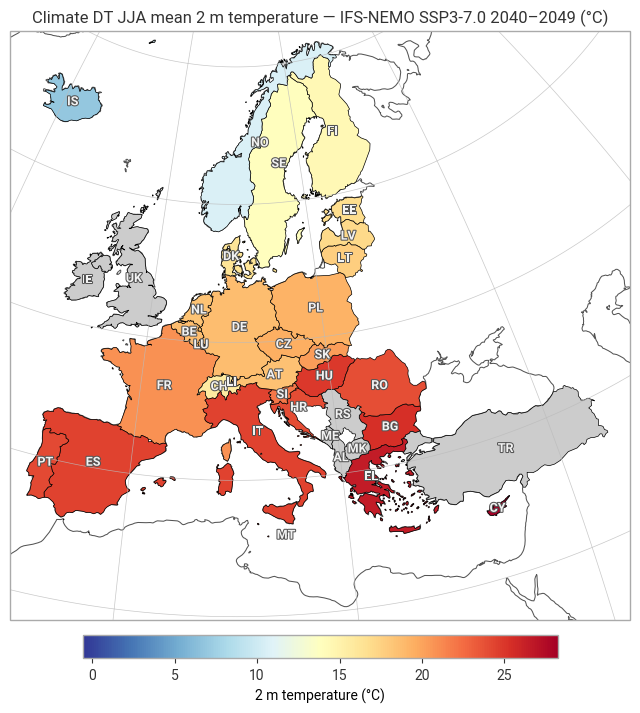

In [25]:
gdf_cdt_future = gdf.merge(
    df_cdt_future,
    left_on="NUTS_ID",
    right_on="geo",
    how="left"
)

if not isinstance(gdf_cdt_future, gpd.GeoDataFrame):
    gdf_cdt_future = gpd.GeoDataFrame(gdf_cdt_future, geometry=gdf.geometry, crs=gdf.crs)

gdf_cdt_future["facecolor"] = gdf_cdt_future["facecolor"].fillna("#cccccc")

chart_cdt_future = earthkit.plots.Map(domain="Europe")
chart_cdt_future.coastlines()
chart_cdt_future.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_cdt_future["facecolor"],
    cmap="RdYlBu_r",
    edgecolor="black",
    linewidth=0.5,
)
chart_cdt_future.gridlines(draw_labels=False)
chart_cdt_future.title(f"Climate DT JJA mean 2 m temperature — {HAZARD_MODEL.upper()} SSP3-7.0 2040–2049 (°C)")
sm_future = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=norm_cdt_both)
sm_future.set_array([])
chart_cdt_future.fig.colorbar(sm_future, ax=chart_cdt_future.ax, orientation="horizontal", pad=0.02, shrink=0.6, label="2 m temperature (°C)")
chart_cdt_future.show()


In [26]:
# ── Build the hazard index ────────────────────────────────────────────────────
# Weights: 60% climate exposure, 40% demographic vulnerability
W_CLIMATE = 0.6
W_VULN    = 0.4

def minmax(arr):
    """Min-max normalise a numpy array to [0, 1]."""
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

# Align elderly data to the country_codes order
elderly_map = df_elderly.set_index('geo')['elderly_pct'].to_dict()
elderly_arr = np.array([elderly_map.get(c, np.nan) for c in country_codes])

# Normalise each pillar
climate_score_hist   = minmax(T_hist_C)
climate_score_future = minmax(T_future_C)
vuln_score           = minmax(elderly_arr)

# Composite scores
hazard_present = W_CLIMATE * climate_score_hist   + W_VULN * vuln_score
hazard_future  = W_CLIMATE * climate_score_future + W_VULN * vuln_score
hazard_delta   = hazard_future - hazard_present

# Assemble into a single DataFrame
df_hazard = pd.DataFrame({
    'geo':            country_codes,
    'T_hist_C':       T_hist_C,
    'T_future_C':     T_future_C,
    'delta_T':        T_future_C - T_hist_C,
    'elderly_pct':    elderly_arr,
    'vuln_score':     vuln_score,
    'hazard_present': hazard_present,
    'hazard_future':  hazard_future,
    'hazard_delta':   hazard_delta,
})

print(df_hazard[['geo', 'T_hist_C', 'T_future_C', 'delta_T', 'elderly_pct',
                 'hazard_present', 'hazard_future', 'hazard_delta']].to_string(index=False))

geo  T_hist_C  T_future_C  delta_T  elderly_pct  hazard_present  hazard_future  hazard_delta
 BE 16.910476   18.731060 1.820584         19.7        0.527632       0.546002      0.018370
 BG 22.484979   25.394799 2.909820         23.5        0.851366       0.898522      0.047156
 CZ 17.283545   19.498181 2.214636         20.4        0.568675       0.597999      0.029324
 DK 14.781042   16.258649 1.477607         20.4        0.497514       0.506943      0.009429
 DE 16.847264   18.736260 1.888996         22.2        0.634530       0.654844      0.020314
 EE 14.814090   16.786881 1.972791         20.3        0.494106       0.517443      0.023337
 EL 24.197162   26.486549 2.289387         23.0        0.878314       0.907470      0.029155
 ES 22.877138   24.501770 1.624633         20.2        0.719039       0.729943      0.010904
 FR 18.927253   20.836085 1.908832         21.1        0.645850       0.666039      0.020189
 HR 21.184729   24.060589 2.875860         22.8        0.783957       

In [27]:
# ── Helper: merge hazard scores onto NUTS shapefile and plot ──────────────────
def plot_hazard_map(gdf_nuts, df_scores, score_col, title, cmap_name="plasma",
                   norm_obj=None, diverging=False):
    """Merge `score_col` from df_scores onto gdf_nuts and render a choropleth.

    Pass `norm_obj` to share a scale across multiple maps (e.g. present/future).
    """
    cmap_obj = plt.get_cmap(cmap_name)
    vals = df_scores[score_col].values
    if norm_obj is None:
        if diverging:
            abs_max = np.nanmax(np.abs(vals))
            norm_obj = plt.Normalize(vmin=-abs_max, vmax=abs_max)
        else:
            norm_obj = plt.Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))

    df_plot = df_scores[['geo', score_col]].copy()
    df_plot['facecolor'] = df_plot[score_col].apply(
        lambda x: plt.cm.colors.to_hex(cmap_obj(norm_obj(x)))
        if not np.isnan(x) else '#cccccc'
    )

    gdf_merged = gdf_nuts.merge(df_plot, left_on='NUTS_ID', right_on='geo', how='left')
    if not isinstance(gdf_merged, gpd.GeoDataFrame):
        gdf_merged = gpd.GeoDataFrame(gdf_merged, geometry=gdf_nuts.geometry,
                                      crs=gdf_nuts.crs)
    gdf_merged['facecolor'] = gdf_merged['facecolor'].fillna('#cccccc')

    chart = earthkit.plots.Map(domain='Europe')
    chart.coastlines()
    chart.shapes(
        shapefile_path,
        labels='NUTS_ID',
        facecolor=gdf_merged['facecolor'],
        cmap=cmap_name,
        edgecolor='black',
        linewidth=0.5,
    )
    chart.gridlines(draw_labels=False)
    chart.title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=norm_obj)
    sm.set_array([])
    chart.fig.colorbar(sm, ax=chart.ax, orientation="horizontal", pad=0.02, shrink=0.6,
                       label="Hazard score (0 = low, 1 = high)")
    chart.show()

print("plot_hazard_map() defined")

plot_hazard_map() defined


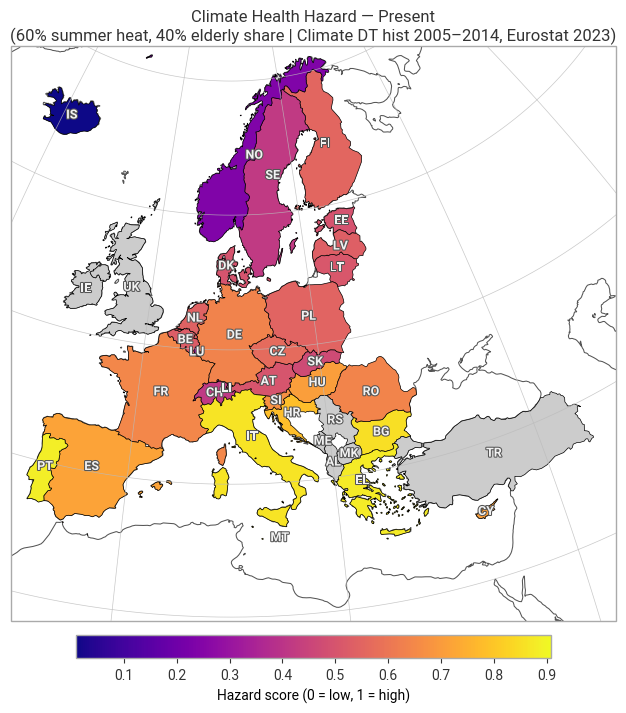

In [28]:
# ── Map 1: Present hazard (hist 2005–2014 + elderly share 2023) ───────────────
# Shared norm across present and future so colours are directly comparable
norm_hazard_both = plt.Normalize(
    vmin=min(df_hazard['hazard_present'].min(), df_hazard['hazard_future'].min()),
    vmax=max(df_hazard['hazard_present'].max(), df_hazard['hazard_future'].max()),
)

plot_hazard_map(
    gdf,
    df_hazard,
    score_col='hazard_present',
    title=(
        f"Climate Health Hazard — Present\n"
        f"({W_CLIMATE:.0%} summer heat, {W_VULN:.0%} elderly share | "
        f"Climate DT hist 2005–2014, Eurostat 2023)"
    ),
    cmap_name='plasma',
    norm_obj=norm_hazard_both,
)

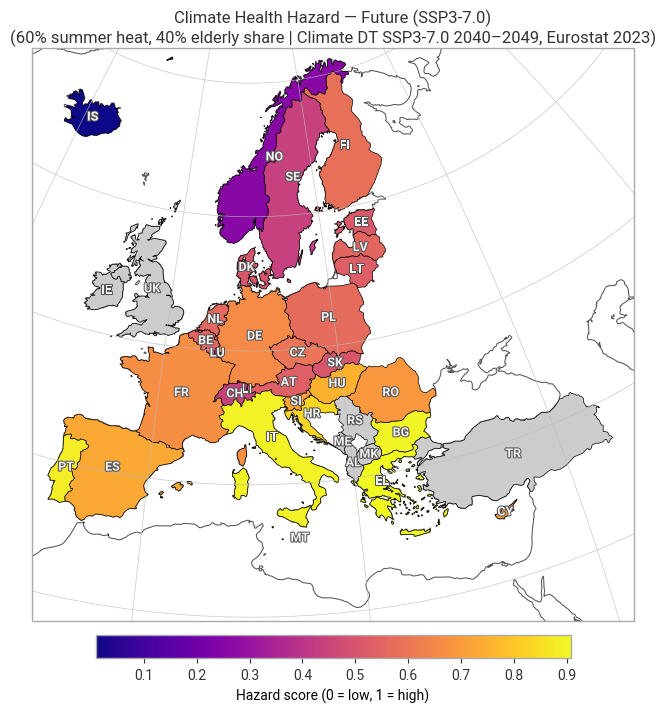

In [29]:
# ── Map 2: Future hazard (SSP3-7.0 2040–2049 + same elderly share) ────────────
plot_hazard_map(
    gdf,
    df_hazard,
    score_col='hazard_future',
    title=(
        f"Climate Health Hazard — Future (SSP3-7.0)\n"
        f"({W_CLIMATE:.0%} summer heat, {W_VULN:.0%} elderly share | "
        f"Climate DT SSP3-7.0 2040–2049, Eurostat 2023)"
    ),
    cmap_name='plasma',
    norm_obj=norm_hazard_both,
)

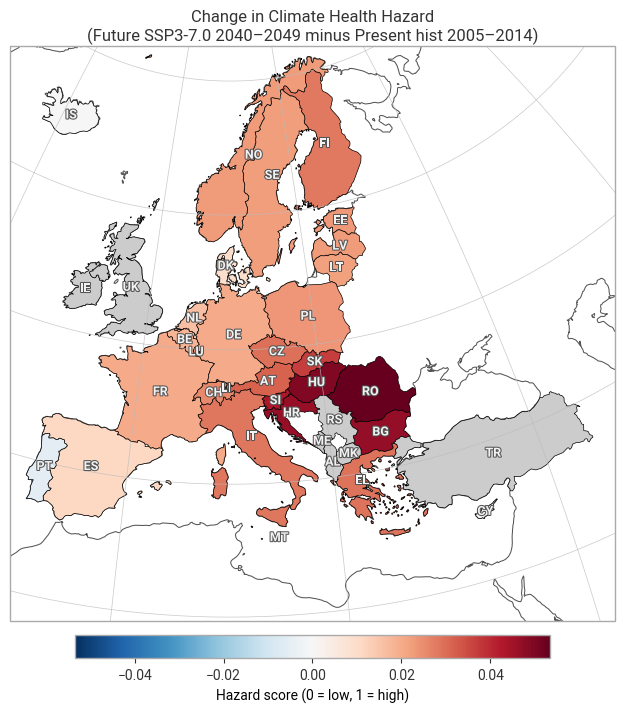

In [30]:
# ── Map 3: Change in hazard (future − present) ────────────────────────────────
# Diverging colormap centred at zero: blue = decreasing risk, red = increasing risk
plot_hazard_map(
    gdf,
    df_hazard,
    score_col='hazard_delta',
    title=(
        "Change in Climate Health Hazard\n"
        "(Future SSP3-7.0 2040–2049 minus Present hist 2005–2014)"
    ),
    cmap_name='RdBu_r',
    diverging=True,
)

In [62]:
# ── Summary table: top 10 countries by future hazard score ───────────────────
top10 = (
    df_hazard[['geo', 'T_hist_C', 'T_future_C', 'delta_T',
               'elderly_pct', 'hazard_present', 'hazard_future', 'hazard_delta']]
    .sort_values('hazard_future', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.columns = [
    'Country', 'T hist (°C)', 'T future (°C)', 'ΔT (°C)',
    'Elderly (%)', 'Hazard present', 'Hazard future', 'Δ Hazard'
]
top10.style.background_gradient(subset=['Hazard future'], cmap='YlOrRd')

,Country,T hist (°C),T future (°C),ΔT (°C),Elderly (%),Hazard present,Hazard future,Δ Hazard
0,BE,27.174231,28.220911,1.046679,16.500000,0.882759,0.868656,-0.014103
1,EE,23.383490,27.541264,4.157773,16.400000,0.780635,0.845717,0.065082
2,LU,20.174766,27.139663,6.964897,15.900000,0.665546,0.801755,0.136209
3,CZ,22.059173,24.093576,2.034403,16.200000,0.733574,0.750548,0.016974
4,DK,23.997736,24.493964,0.496229,16.000000,0.768479,0.746205,-0.022274
5,FR,17.862375,20.704998,2.842623,17.200000,0.697112,0.739532,0.042420
6,DE,26.434671,28.818417,2.383746,14.000000,0.691766,0.710345,0.018578
7,BG,24.295958,26.445304,2.149345,14.200000,0.651833,0.668125,0.016292
8,RO,15.364562,20.554076,5.189514,16.200000,0.565399,0.667005,0.101605
9,SE,12.627318,16.452506,3.825188,17.400000,0.579396,0.652953,0.073557
